In [1]:
import pandas as pd 
df= pd.read_excel("data/Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
print("Rows and Columns", df.shape)

df.info()

Rows and Columns (541909, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [3]:
print("Missing values:")
print(df.isna().sum())

print("\n First transaction:", df["InvoiceDate"].min())
print("Last transaction", df["InvoiceDate"].max())

print("\n Negative quantities:", (df["Quantity"] < 0).sum())
print("Zero quantities", (df["Quantity"] == 0).sum())
print("Zero or negative prices:", (df["UnitPrice"]<=0).sum())

cancelled = (
    df["InvoiceNo"]
    .astype(str)
    .str.upper()
    .str.startswith("C")
)

print("Rows with cancellation invoices:", cancelled.sum())

print("Exact duplicate rows:", df.duplicated().sum())

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

 First transaction: 2010-12-01 08:26:00
Last transaction 2011-12-09 12:50:00

 Negative quantities: 10624
Zero quantities 0
Zero or negative prices: 2517
Rows with cancellation invoices: 9288
Exact duplicate rows: 5268


In [4]:
cancelled = (
    df["InvoiceNo"]
    .astype(str)
    .str.upper()
    .str.startswith("C")
)
valid_sale = (
    (df["Quantity"] > 0)
    & (df["UnitPrice"] > 0)
    & (~cancelled)
)
sales= df.loc[valid_sale].copy()

sales = sales.sort_values("InvoiceDate")

print("Original Rows:", len(df))
print("Rows retained:", len(sales))
print("Rows excluded:", len(df) - len(sales))

Original Rows: 541909
Rows retained: 530104
Rows excluded: 11805


In [5]:
print(
    "Exact duplicate rows in filtered data:", 
    sales.duplicated().sum()
)

duplicate_examples = sales.loc[
    sales.duplicated(keep=False)
]

duplicate_examples.sort_values(
    ["InvoiceNo", "StockCode", "InvoiceDate"]
).head(12)

Exact duplicate rows in filtered data: 5226


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
598,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom
601,536412,21448,12 DAISY PEGS IN WOOD BOX,2,2010-12-01 11:49:00,1.65,17920.0,United Kingdom


In [6]:
sales_clean = sales.drop_duplicates().copy()
print("Before removing duplicates:", len(sales))
print("After removing duplicates:", len(sales_clean))
print("Duplicates remaining:", sales_clean.duplicated().sum())

Before removing duplicates: 530104
After removing duplicates: 524878
Duplicates remaining: 0


In [7]:
selection_data = sales_clean.loc[
    sales_clean["InvoiceDate"] < pd.Timestamp("2011-10-03")
].copy()
product_summary = (
    selection_data.groupby("StockCode")
    .agg(
        Description = ("Description", "first"),
        UnitsSold = ("Quantity","sum"),
        InvoiceCount = ("InvoiceNo", "nunique"),
        FirstSale = ("InvoiceDate", "min"),
        LastSale = ("InvoiceDate", "max")
    )
    .sort_values("InvoiceCount", ascending=False)
)

display(product_summary.head(10))

,Description,UnitsSold,InvoiceCount,FirstSale,LastSale
StockCode,,,,,
85123A,WHITE HANGING HEART T-LIGHT HOLDER,30254,1732,2010-12-01 08:26:00,2011-10-02 15:49:00
85099B,JUMBO BAG RED RETROSPOT,35952,1603,2010-12-01 09:57:00,2011-10-02 13:26:00
22423,REGENCY CAKESTAND 3 TIER,11273,1564,2010-12-01 12:27:00,2011-10-02 15:07:00
47566,PARTY BUNTING,16621,1473,2010-12-03 11:27:00,2011-10-02 15:49:00
20725,LUNCH BAG RED RETROSPOT,15688,1244,2010-12-01 09:37:00,2011-09-30 17:22:00
84879,ASSORTED COLOUR BIRD ORNAMENT,27085,1060,2010-12-01 08:34:00,2011-10-02 14:47:00
21212,PACK OF 72 RETROSPOT CAKE CASES,31252,1041,2010-12-01 09:37:00,2011-10-02 15:52:00
22720,SET OF 3 CAKE TINS PANTRY DESIGN,6138,1037,2010-12-13 15:13:00,2011-10-02 14:56:00
22383,LUNCH BAG SUKI DESIGN,10714,1022,2010-12-01 11:29:00,2011-10-02 15:52:00


In [8]:
product_code = "85123A"

product_sales = sales_clean.loc[
    sales_clean["StockCode"].astype(str) == product_code
].copy()

weekly_sales=(
    product_sales
    .resample("W-SUN", on="InvoiceDate")["Quantity"]
    .sum()
    .rename("UnitsSold")
)


week_ends = pd.date_range(
    start="2010-12-12",
    end="2011-12-04",
    freq="W-SUN"
)


weekly_sales = weekly_sales.reindex(week_ends, fill_value=0)
weekly_sales.index.name = "WeekEnding"

cutoff = pd.Timestamp("2011-10-03")

train = weekly_sales.loc[weekly_sales.index < cutoff]
test = weekly_sales.loc[weekly_sales.index >= cutoff]

print("Total complete weeks:", len(weekly_sales))
print("Training weeks:", len(train))
print("Test weeks:", len(test))

display(train.head(6).to_frame())

Total complete weeks: 52
Training weeks: 43
Test weeks: 9


,UnitsSold
WeekEnding,
2010-12-12,1045
2010-12-19,1524
2010-12-26,197
2011-01-02,0
2011-01-09,973
2011-01-16,3328


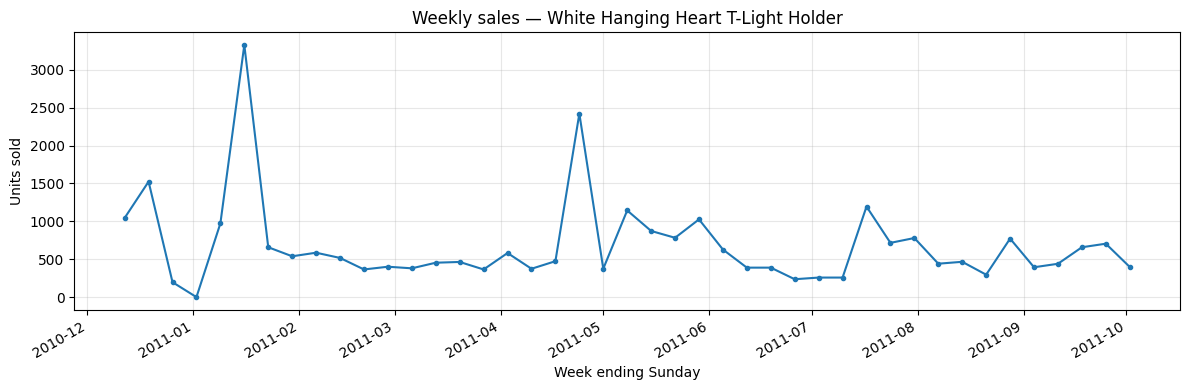

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,4))

ax.plot(train.index, train.values, marker="o", markersize=3)
ax.set_title("Weekly sales — White Hanging Heart T-Light Holder")
ax.set_xlabel("Week ending Sunday")
ax.set_ylabel("Units sold")
ax.grid(alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [10]:
week_start = pd.Timestamp("2010-12-27")
week_end = pd.Timestamp("2011-01-03")

week_records = df.loc[
    (df["InvoiceDate"] >= week_start)
    & (df["InvoiceDate"] < week_end)
]

print("All dataset rows during this week:", len(week_records))

All dataset rows during this week: 0


In [11]:
display(train.tail(3).to_frame())

last_value_forecast = train.iloc[-1]
moving_average_forecast = train.tail(3).mean()

print("Forecasts for the week ending 2011-10-09:")
print(f"Last-vale forecast: {last_value_forecast: .1f} units")
print(f"Three-week moving average: {moving_average_forecast: .1f} units")

,UnitsSold
WeekEnding,
2011-09-18,658
2011-09-25,705
2011-10-02,398


Forecasts for the week ending 2011-10-09:
Last-vale forecast:  398.0 units
Three-week moving average:  587.0 units


In [12]:
weekly_sales = weekly_sales.astype(float)
weekly_sales.loc[pd.Timestamp("2011-01-02")] = float("nan")

train = weekly_sales.loc[weekly_sales.index < cutoff]
test = weekly_sales.loc[weekly_sales.index >= cutoff]

In [13]:
previous_week = train.shift(1)
previous_three_average = previous_week.rolling(
    window=3,
    min_periods=3
).mean()

validation_results = pd.DataFrame({
    "Actual": train,
    "LastValue": previous_week,
    "MovingAverage3": previous_three_average
}).iloc[-8:].copy()

display(validation_results)

,Actual,LastValue,MovingAverage3
WeekEnding,,,
2011-08-14,466.0,441.0,645.666667
2011-08-21,296.0,466.0,562.333333
2011-08-28,772.0,296.0,401.000000
2011-09-04,394.0,772.0,511.333333
2011-09-11,440.0,394.0,487.333333
2011-09-18,658.0,440.0,535.333333
2011-09-25,705.0,658.0,497.333333
2011-10-02,398.0,705.0,601.000000


In [14]:
scored = validation_results.dropna().copy()

scored["LastValueError"] = (
    scored["Actual"] - scored["LastValue"]
).abs()

scored["MovingAverage3Error"] = (
    scored["Actual"] - scored["MovingAverage3"]
).abs()

print("Validation weeks scored:", len(scored))
print(f"Last-value MAE: {scored['LastValueError'].mean():.2f} units")
print(f"moving_average MAE: {scored['MovingAverage3Error'].mean():.2f} units")

display(scored)

Validation weeks scored: 8
Last-value MAE: 208.38 units
moving_average MAE: 189.38 units


,Actual,LastValue,MovingAverage3,LastValueError,MovingAverage3Error
WeekEnding,,,,,
2011-08-14,466.0,441.0,645.666667,25.0,179.666667
2011-08-21,296.0,466.0,562.333333,170.0,266.333333
2011-08-28,772.0,296.0,401.000000,476.0,371.000000
2011-09-04,394.0,772.0,511.333333,378.0,117.333333
2011-09-11,440.0,394.0,487.333333,46.0,47.333333
2011-09-18,658.0,440.0,535.333333,218.0,122.666667
2011-09-25,705.0,658.0,497.333333,47.0,207.666667
2011-10-02,398.0,705.0,601.000000,307.0,203.000000


In [15]:
validation_dates = train.index[-8:]
actual = train.loc[validation_dates]

forecasts = pd.DataFrame(index=validation_dates)

forecasts["LastValue"] = train.shift(1)

for window in [2, 3, 4, 6]:
    forecasts[f"MA{window}"] = (
        train.shift(1)
        .rolling(window=window, min_periods=window)
        .mean()
    )

valid = actual.notna() & forecasts.notna().all(axis=1)

errors = forecasts.loc[valid].sub(
    actual.loc[valid], axis=0
).abs()

leaderboard = (
    errors.mean()
    .rename("ValidationMAE")
    .sort_values()
    .to_frame()
)

print("Validation weeks scored:", valid.sum())
display(leaderboard)

Validation weeks scored: 8


,ValidationMAE
MA6,177.208333
MA4,189.062500
MA3,189.375000
MA2,207.062500
LastValue,208.375000


In [16]:
ml_data = pd.DataFrame({
    "Target": train,
    "Lag1": train.shift(1),
    "Lag2": train.shift(2),
    "Lag3": train.shift(3)
})

complete_rows = ml_data.dropna().copy()

validation_start = train.index[-8]

fit_data = complete_rows.loc[
    complete_rows.index < validation_start
]

validation_data = complete_rows.loc[
    complete_rows.index >= validation_start
]

print("Initial model-fitting rows:", len(fit_data))
print("Validation rows:", len(validation_data))

display(validation_data)

Initial model-fitting rows: 28
Validation rows: 8


,Target,Lag1,Lag2,Lag3
WeekEnding,,,,
2011-08-14,466.0,441.0,780.0,716.0
2011-08-21,296.0,466.0,441.0,780.0
2011-08-28,772.0,296.0,466.0,441.0
2011-09-04,394.0,772.0,296.0,466.0
2011-09-11,440.0,394.0,772.0,296.0
2011-09-18,658.0,440.0,394.0,772.0
2011-09-25,705.0,658.0,440.0,394.0
2011-10-02,398.0,705.0,658.0,440.0


In [17]:
from sklearn.linear_model import LinearRegression

features = ["Lag1", "Lag2", "Lag3"]
records = []
for date in validation_data.index:
    history = complete_rows.loc[complete_rows.index < date]
    
    X_history = history[features]
    Y_history = history["Target"]

    model = LinearRegression()
    model.fit(X_history,Y_history)

    X_next = validation_data.loc[[date], features]
    raw_prediction = float(model.predict(X_next)[0])

    prediction = max(0.0, raw_prediction)

    records.append({
        "WeekEnding":date,
        "Actual": validation_data.loc[date, "Target"],
        "LinearRegression": prediction,
        "FittingRows": len(history)
    })

regression_results = (
    pd.DataFrame(records)
    .set_index("WeekEnding")
)

display(regression_results)

,Actual,LinearRegression,FittingRows
WeekEnding,,,
2011-08-14,466.0,627.887843,28
2011-08-21,296.0,601.407749,29
2011-08-28,772.0,582.613635,30
2011-09-04,394.0,578.715117,31
2011-09-11,440.0,605.031721,32
2011-09-18,658.0,581.818224,33
2011-09-25,705.0,575.763002,34
2011-10-02,398.0,595.927264,35


In [18]:
ma6 = train.shift(1).rolling(
    window=6,
    min_periods=6
).mean()

regression_results["MA6"] = ma6.reindex(
    regression_results.index
)

regression_results["RegressionError"] = (
    regression_results["Actual"] - regression_results["LinearRegression"]
).abs()

regression_results["MA6Error"] = (
    regression_results["Actual"] - regression_results["MA6"]
).abs()

print(
    "Regrssion MAE:",
    round(regression_results["RegressionError"].mean(), 2)
)

print(
    "Six-week average MAE:",
    round(regression_results["MA6Error"].mean(), 2)
)

display(regression_results.round(2))

Regrssion MAE: 176.22
Six-week average MAE: 177.21


,Actual,LinearRegression,FittingRows,MA6,RegressionError,MA6Error
WeekEnding,,,,,,
2011-08-14,466.0,627.89,28,608.00,161.89,142.00
2011-08-21,296.0,601.41,29,642.67,305.41,346.67
2011-08-28,772.0,582.61,30,649.00,189.39,123.00
2011-09-04,394.0,578.72,31,578.50,184.72,184.50
2011-09-11,440.0,605.03,32,524.83,165.03,84.83
2011-09-18,658.0,581.82,33,468.17,76.18,189.83
2011-09-25,705.0,575.76,34,504.33,129.24,200.67
2011-10-02,398.0,595.93,35,544.17,197.93,146.17


In [19]:
all_ml_data = pd.DataFrame({
    "Target": weekly_sales,
    "Lag1": weekly_sales.shift(1),
    "Lag2": weekly_sales.shift(2),
    "Lag3": weekly_sales.shift(3)
})

features = ["Lag1", "Lag2", "Lag3"]
test_records = []

for date in test.index:

    history = all_ml_data.loc[
        all_ml_data.index < date
    ].dropna(subset=["Target"] + features)

    model = LinearRegression()
    model.fit(history[features], history["Target"])

    X_next = all_ml_data.loc[[date], features]
    regression_prediction = max(
        0.0,
        float(model.predict(X_next)[0])
    )

    past_sales = weekly_sales.loc[
        weekly_sales.index < date
    ]

    ma6_prediction = past_sales.tail(6).mean(skipna=False)

    test_records.append({
        "WeekEnding": date,
        "Actual": test.loc[date],
        "LinearRegression": regression_prediction,
        "MA6": ma6_prediction
    })

test_results = pd.DataFrame(test_records).set_index("WeekEnding")

In [20]:
test_scored = test_results.dropna(
    subset=["Actual", "LinearRegression", "MA6"]
).copy()

test_scored["RegressionError"] = (
    test_scored["Actual"] - test_scored["LinearRegression"]
).abs()

test_scored["MA6Error"] = (
    test_scored["Actual"] - test_scored["MA6"]
).abs()

print("Test weeks scored:", len(test_scored))
print(
    "Regression test MAE:",
    round(test_scored["RegressionError"].mean(), 2)
)
print(
    "Six-week average test MAE:",
    round(test_scored["MA6Error"].mean(), 2)
)

display(test_scored.round(2))

Test weeks scored: 9
Regression test MAE: 355.1
Six-week average test MAE: 345.91


,Actual,LinearRegression,MA6,RegressionError,MA6Error
WeekEnding,,,,,
2011-10-09,163.0,602.36,561.17,439.36,398.17
2011-10-16,679.0,568.05,459.67,110.95,219.33
2011-10-23,231.0,548.67,507.17,317.67,276.17
2011-10-30,444.0,568.30,472.33,124.30,28.33
2011-11-06,1702.0,546.27,436.67,1155.73,1265.33
2011-11-13,575.0,540.49,602.83,34.51,27.83
2011-11-20,1322.0,633.32,632.33,688.68,689.67
2011-11-27,897.0,621.92,825.50,275.08,71.50
2011-12-04,725.0,675.36,861.83,49.64,136.83


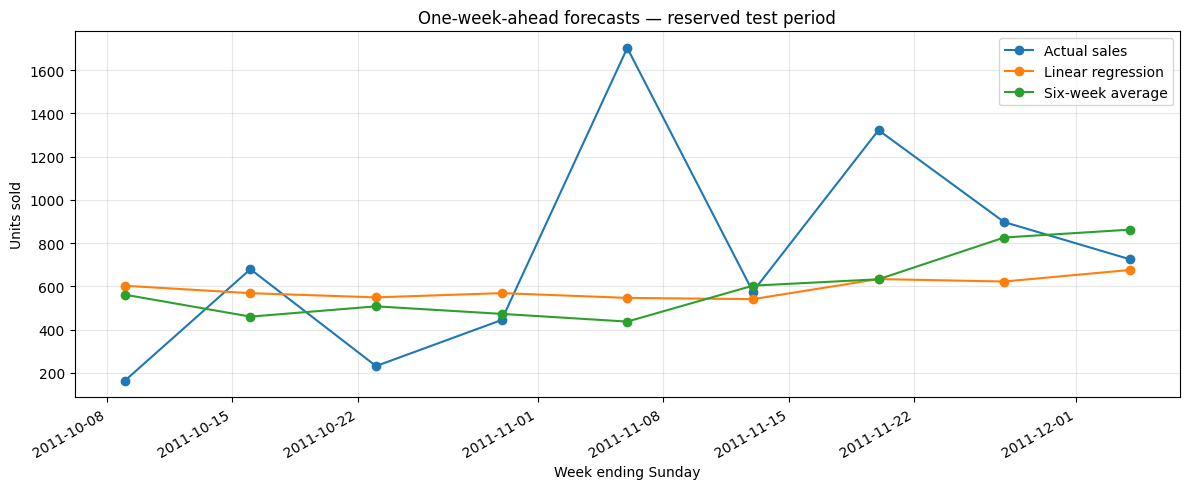

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    test_results.index,
    test_results["Actual"],
    marker="o",
    label="Actual sales"
)

ax.plot(
    test_results.index,
    test_results["LinearRegression"],
    marker="o",
    label="Linear regression"
)

ax.plot(
    test_results.index,
    test_results["MA6"],
    marker="o",
    label="Six-week average"
)

ax.set_title("One-week-ahead forecasts — reserved test period")
ax.set_xlabel("Week ending Sunday")
ax.set_ylabel("Units sold")
ax.legend()
ax.grid(alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [22]:
spike_start = pd.Timestamp("2011-10-31")
spike_end = pd.Timestamp("2011-11-07")

spike_sales = product_sales.loc[
    (product_sales["InvoiceDate"] >= spike_start)
    & (product_sales["InvoiceDate"] < spike_end)
].copy()

invoice_units = (
    spike_sales.groupby("InvoiceNo")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

print("Weekly units:", spike_sales["Quantity"].sum())
print("Number of invoices:", len(invoice_units))

display(
    invoice_units.head(10).to_frame(name="ProductUnits")
)

Weekly units: 1702
Number of invoices: 51


,ProductUnits
InvoiceNo,
574293,992
574285,224
573483,32
573695,32
574736,32
574311,32
574328,32
574055,32
574062,32


In [23]:
total_units = invoice_units.sum()

largest_share = 100 * invoice_units.iloc[0] / total_units
top_three_share = 100 * invoice_units.head(3).sum() / total_units

print(f"Largest invoice's share: {largest_share:.1f}%")
print(f"Top three invoices' combined share: {top_three_share:.1f}%")

Largest invoice's share: 58.3%
Top three invoices' combined share: 73.3%


In [24]:
from pathlib import Path

output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

metrics = pd.DataFrame({
    "Model": ["LinearRegression", "MA6"],
    "ValidationMAE": [
        regression_results["RegressionError"].mean(),
        regression_results["MA6Error"].mean()
    ],
    "TestMAE": [
        test_scored["RegressionError"].mean(),
        test_scored["MA6Error"].mean()
    ]
})

metrics.to_csv(output_dir / "metrics.csv", index=False)

regression_results.to_csv(
    output_dir / "validation_predictions.csv"
)

test_scored.to_csv(
    output_dir / "test_predictions.csv"
)

# Save the test comparison chart created earlier
fig.savefig(
    output_dir / "test_forecasts.png",
    dpi=160,
    bbox_inches="tight"
)

display(metrics.round(2))

,Model,ValidationMAE,TestMAE
0,LinearRegression,176.22,355.10
1,MA6,177.21,345.91


In [25]:
def build_weekly_sales(
    sales_data,
    product_code,
    week_ends,
    unknown_weeks=()
):
    # Select the requested product
    product_rows = sales_data.loc[
        sales_data["StockCode"].astype(str) == str(product_code)
    ].copy()

    if product_rows.empty:
        raise ValueError(f"No sales found for product {product_code}")

    # Aggregate transactions into Monday–Sunday weeks
    weekly = (
        product_rows
        .resample("W-SUN", on="InvoiceDate")["Quantity"]
        .sum()
        .rename("UnitsSold")
    )

    # Keep the specified calendar and mark known uncertainties
    weekly = weekly.reindex(week_ends, fill_value=0).astype(float)
    weekly.index.name = "WeekEnding"

    unknown_dates = pd.to_datetime(list(unknown_weeks))
    weekly.loc[weekly.index.isin(unknown_dates)] = float("nan")

    return weekly

In [26]:
rebuilt_sales = build_weekly_sales(
    sales_data=sales_clean,
    product_code="85123A",
    week_ends=week_ends,
    unknown_weeks=["2011-01-02"]
)

pd.testing.assert_series_equal(rebuilt_sales, weekly_sales)

print("Passed: the function reproduces our original weekly series.")

Passed: the function reproduces our original weekly series.


In [27]:
bag_sales = build_weekly_sales(
    sales_data=sales_clean,
    product_code="85099B",
    week_ends=week_ends,
    unknown_weeks=["2011-01-02"]
)

display(bag_sales.head().to_frame())

,UnitsSold
WeekEnding,
2010-12-12,852.0
2010-12-19,427.0
2010-12-26,180.0
2011-01-02,NaN
2011-01-09,1374.0


In [28]:
def walk_forward_forecasts(weekly, evaluation_dates):
    data = pd.DataFrame({"Target": weekly})
    features = ["Lag1", "Lag2", "Lag3"]

    for lag in [1, 2, 3]:
        data[f"Lag{lag}"] = weekly.shift(lag)

    ma6 = weekly.shift(1).rolling(
        window=6,
        min_periods=6
    ).mean()

    records = []

    for date in evaluation_dates:
        history = data.loc[
            data.index < date
        ].dropna(subset=["Target"] + features)

        X_next = data.loc[[date], features]

        prediction = float("nan")

        if not history.empty and not X_next.isna().any().any():
            model = LinearRegression()
            model.fit(history[features], history["Target"])

            prediction = max(
                0.0,
                float(model.predict(X_next)[0])
            )

        records.append({
            "WeekEnding": date,
            "Actual": weekly.loc[date],
            "LinearRegression": prediction,
            "MA6": ma6.loc[date]
        })

    return pd.DataFrame(records).set_index("WeekEnding")

In [29]:
rebuilt_test = walk_forward_forecasts(
    weekly=weekly_sales,
    evaluation_dates=test.index
)

pd.testing.assert_frame_equal(rebuilt_test, test_results)

print("Passed: the function reproduces our original test predictions.")

Passed: the function reproduces our original test predictions.


In [30]:
weekly = build_weekly_sales(
    sales_clean,
    "85123A",
    week_ends,
    unknown_weeks=["2011-01-02"]
)

predictions = walk_forward_forecasts(
    weekly,
    test.index
)